# Дальняя зона, дробная задержка и детерминированное распространение

Notebook независимо проверяет геометрическую и интерполяционную части генератора. Здесь нет случайного шума, отражений, ветра, GCC-PHAT, SRP-PHAT или модели гармоник БПЛА. Диагностические значения $f_s=48$ кГц, $f_{max}=2,4,8,12$ кГц, 0.1 отсчёта и 0.1 рад не считаются окончательными характеристиками реального источника.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / 'model').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from model.geometry import all_pairs, comparison_arrays
from model.tdoa import directional_spherical_tdoa, far_field_tdoa, second_order_tdoa
from simulation.propagation import simulate_propagation
from simulation.signals import deterministic_bandlimited_signal
from validation.far_field import direction_grid, far_field_error
from validation.propagation_study import (
    DIAGNOSTIC_MAXIMUM_FREQUENCIES_HZ, DIAGNOSTIC_PHASE_ERROR_LIMIT_RAD,
    DIAGNOSTIC_SAMPLE_ERROR_LIMIT, DIAGNOSTIC_SAMPLING_RATE_HZ, DISTANCES_M,
    FINAL_ANGULAR_STEP_DEG, REFINED_ANGULAR_STEP_DEG, FRACTIONAL_DELAYS_SAMPLES,
    FRACTIONAL_TEST_FREQUENCIES_HZ, run_far_field_boundary_study,
    run_fractional_delay_accuracy_study,
)

FAR_FIELD_CSV = project_root / 'results' / 'far_field_boundary.csv'
DELAY_CSV = project_root / 'results' / 'fractional_delay_accuracy.csv'
print('Python:', platform.python_version())
print('NumPy:', np.__version__, 'Matplotlib:', matplotlib.__version__)
print('coarse/refined angular steps:', FINAL_ANGULAR_STEP_DEG, REFINED_ANGULAR_STEP_DEG, 'deg')


Python: 3.11.7
NumPy: 2.4.6 Matplotlib: 3.11.1
coarse/refined angular steps: 0.5 0.25 deg


## Расчёт $E_\tau(R)$ и численных границ

Azimuth использует полуоткрытый интервал $[0°,360°)$ без дублирования. Сетки 0.5° и 0.25° содержат соответственно 115920 и 462240 направлений. Итоговый $R_{min}$ ищется на refined-сетке 0.25°, а оба максимума повторно вычисляются при одном расстоянии.

far-field records: 80 sweep: 55 boundaries: 25
CSV: C:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model\results\far_field_boundary.csv


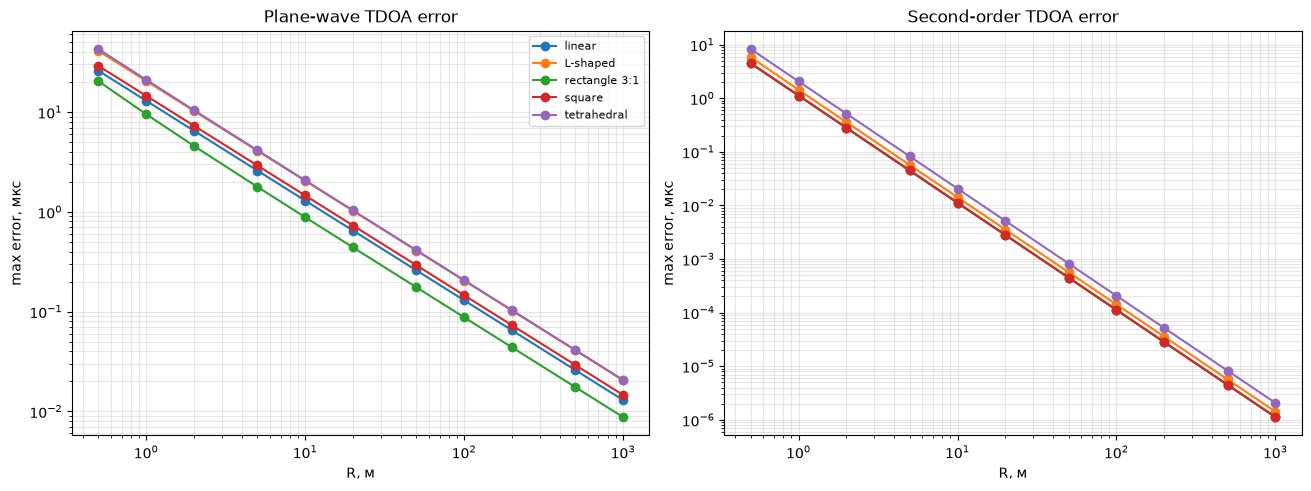

In [2]:
far_records = run_far_field_boundary_study(output_csv=FAR_FIELD_CSV)
sweep = [row for row in far_records if row['record_type'] == 'distance_sweep']
boundaries = [row for row in far_records if row['record_type'] == 'boundary']
print('far-field records:', len(far_records), 'sweep:', len(sweep), 'boundaries:', len(boundaries))
print('CSV:', FAR_FIELD_CSV)

arrays = comparison_arrays()
colors = dict(zip(arrays, plt.cm.tab10.colors))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for name in arrays:
    rows = [row for row in sweep if row['geometry'] == name]
    distances = np.asarray([row['distance_m'] for row in rows])
    axes[0].loglog(distances, [row['max_plane_error_us'] for row in rows], 'o-', label=name, color=colors[name])
    axes[1].loglog(distances, [row['max_second_order_error_us'] for row in rows], 'o-', label=name, color=colors[name])
axes[0].set_title('Plane-wave TDOA error')
axes[1].set_title('Second-order TDOA error')
for axis in axes:
    axis.set_xlabel('R, м')
    axis.set_ylabel('max error, мкс')
    axis.grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=8)
plt.show()


## Фазовая ошибка и минимальные расстояния

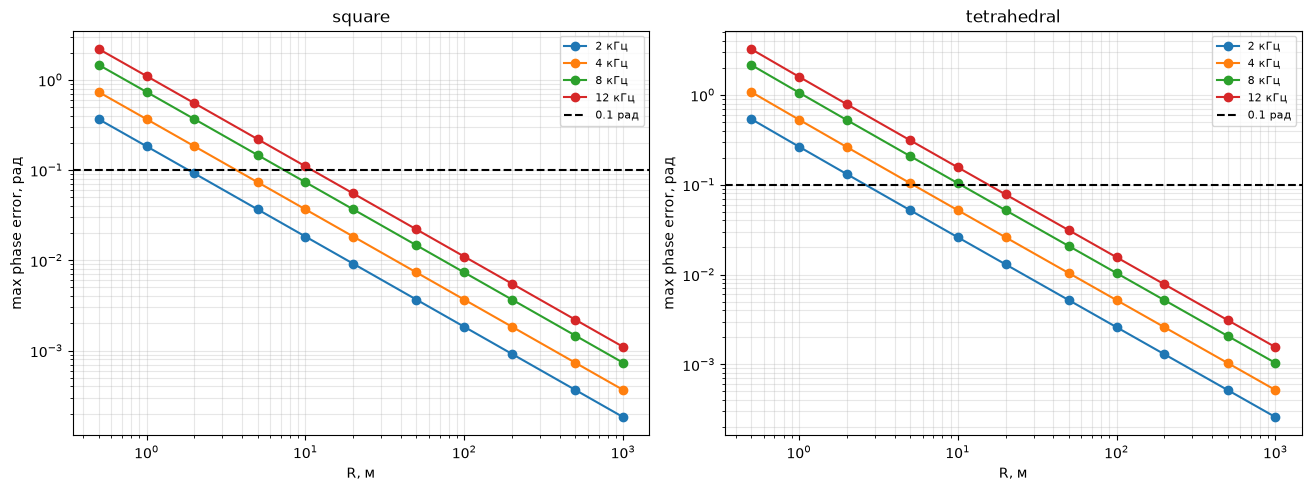

| Геометрия | Критерий | f_max, Гц | min R, м | grid diff | refined worst az/el | пара |
|---|---|---:|---:|---:|---:|---|
| linear | sample | - | 6.2197 | 0.000e+00 | 89.00°/57.50° | 1-3 |
| linear | phase | 2000 | 1.6287 | 2.147e-09 | 265.00°/65.75° | 0-2 |
| linear | phase | 4000 | 3.2568 | 7.170e-11 | 267.50°/65.75° | 0-2 |
| linear | phase | 8000 | 6.5133 | 0.000e+00 | 268.50°/70.00° | 0-2 |
| linear | phase | 12000 | 9.7698 | 0.000e+00 | 89.00°/70.00° | 1-3 |
| L-shaped | sample | - | 9.8090 | 0.000e+00 | 28.50°/0.00° | 0-3 |
| L-shaped | phase | 2000 | 2.5702 | 6.670e-06 | 29.25°/0.00° | 0-3 |
| L-shaped | phase | 4000 | 5.1375 | 6.019e-06 | 28.75°/0.00° | 0-3 |
| L-shaped | phase | 8000 | 10.2718 | 0.000e+00 | 28.50°/0.00° | 0-3 |
| L-shaped | phase | 12000 | 15.4060 | 1.045e-05 | 28.25°/0.00° | 0-3 |
| rectangle 3:1 | sample | - | 4.2853 | 1.858e-06 | 134.75°/0.00° | 0-1 |
| rectangle 3:1 | phase | 2000 | 1.1804 | 1.930e-05 | 134.75°/0.00° | 0-1 |
| rectangle 3:1 | phase | 4000 | 2.2833 | 2.797e-05 | 134.75°/0.00° | 0-1 |
| rectangle 3:1 | phase | 8000 | 4.4836 | 3.250e-07 | 134.75°/0.00° | 0-1 |
| rectangle 3:1 | phase | 12000 | 6.6825 | 0.000e+00 | 225.00°/0.00° | 2-3 |
| square | sample | - | 6.9969 | 2.455e-05 | 44.75°/0.00° | 0-1 |
| square | phase | 2000 | 1.8312 | 2.146e-05 | 314.25°/0.00° | 0-3 |
| square | phase | 4000 | 3.6633 | 0.000e+00 | 44.50°/0.00° | 0-1 |
| square | phase | 8000 | 7.3272 | 2.173e-05 | 44.75°/0.00° | 0-1 |
| square | phase | 12000 | 10.9908 | 1.794e-06 | 315.25°/0.00° | 2-3 |
| tetrahedral | sample | - | 9.9200 | 0.000e+00 | 305.50°/30.00° | 0-2 |
| tetrahedral | phase | 2000 | 2.6142 | 4.214e-07 | 324.25°/30.25° | 2-3 |
| tetrahedral | phase | 4000 | 5.2055 | 4.636e-06 | 135.00°/44.75° | 1-2 |
| tetrahedral | phase | 8000 | 10.3870 | 0.000e+00 | 305.50°/30.00° | 0-2 |
| tetrahedral | phase | 12000 | 15.5683 | 0.000e+00 | 135.00°/45.00° | 1-2 |

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for axis, geometry in zip(axes, ('square', 'tetrahedral')):
    rows = [row for row in sweep if row['geometry'] == geometry]
    distances = np.asarray([row['distance_m'] for row in rows])
    for frequency in DIAGNOSTIC_MAXIMUM_FREQUENCIES_HZ:
        key = f'phase_error_{int(frequency)}hz_rad'
        axis.loglog(distances, [row[key] for row in rows], 'o-', label=f'{frequency/1000:g} кГц')
    axis.axhline(DIAGNOSTIC_PHASE_ERROR_LIMIT_RAD, color='black', linestyle='--', label='0.1 рад')
    axis.set_title(geometry)
    axis.set_xlabel('R, м')
    axis.set_ylabel('max phase error, рад')
    axis.grid(True, which='both', alpha=0.3)
    axis.legend(fontsize=8)
plt.show()

header = '| Геометрия | Критерий | f_max, Гц | min R, м | grid diff | refined worst az/el | пара |\n|---|---|---:|---:|---:|---:|---|\n'
lines = []
for row in boundaries:
    frequency = '-' if row.get('maximum_frequency_hz') is None else f"{row['maximum_frequency_hz']:.0f}"
    lines.append(f"| {row['geometry']} | {row['criterion']} | {frequency} | {row['minimum_distance_m']:.4f} | {row['relative_grid_difference']:.3e} | {row['refined_worst_azimuth_deg']:.2f}°/{row['refined_worst_elevation_deg']:.2f}° | {row['refined_worst_pair']} |")
display(Markdown(header + '\n'.join(lines)))


## Сходимость угловой сетки

Для каждой из 25 границ показан независимый пересчёт maximum на 0.5° и 0.25°. При расхождении выше $10^{-4}$ автоматически запускается локальное непрерывное уточнение около 12 лучших grid-кандидатов.

In [4]:
for row in boundaries:
    print(f"{row['geometry']:14s} {row['criterion']:6s} f={row.get('maximum_frequency_hz') or 0:5.0f}: coarse={row['coarse_max_error']*1e6:.6f} us, refined={row['refined_max_error']*1e6:.6f} us, rel={row['relative_grid_difference']:.3e}")
max_grid_difference = max(row['relative_grid_difference'] for row in boundaries)
continuous_count = sum(bool(row['continuous_refinement_used']) for row in boundaries)
print('maximum relative grid difference:', max_grid_difference)
print('continuous refinements triggered:', continuous_count)
assert max_grid_difference <= 1e-4


linear         sample f=    0: coarse=2.083333 us, refined=2.083333 us, rel=0.000e+00
linear         phase  f= 2000: coarse=7.957742 us, refined=7.957742 us, rel=2.147e-09
linear         phase  f= 4000: coarse=3.978869 us, refined=3.978869 us, rel=7.170e-11
linear         phase  f= 8000: coarse=1.989436 us, refined=1.989436 us, rel=0.000e+00
linear         phase  f=12000: coarse=1.326290 us, refined=1.326290 us, rel=0.000e+00
L-shaped       sample f=    0: coarse=2.083332 us, refined=2.083332 us, rel=0.000e+00
L-shaped       phase  f= 2000: coarse=7.957693 us, refined=7.957746 us, rel=6.670e-06
L-shaped       phase  f= 4000: coarse=3.978846 us, refined=3.978870 us, rel=6.019e-06
L-shaped       phase  f= 8000: coarse=1.989435 us, refined=1.989435 us, rel=0.000e+00
L-shaped       phase  f=12000: coarse=1.326277 us, refined=1.326291 us, rel=1.045e-05
rectangle 3:1  sample f=    0: coarse=2.083327 us, refined=2.083331 us, rel=1.858e-06
rectangle 3:1  phase  f= 2000: coarse=7.957593 us, ref

## Exact spherical, plane и второй порядок

Показана одна и та же ориентированная TDOA; знак plane-модели совпадает со сферическим пределом.

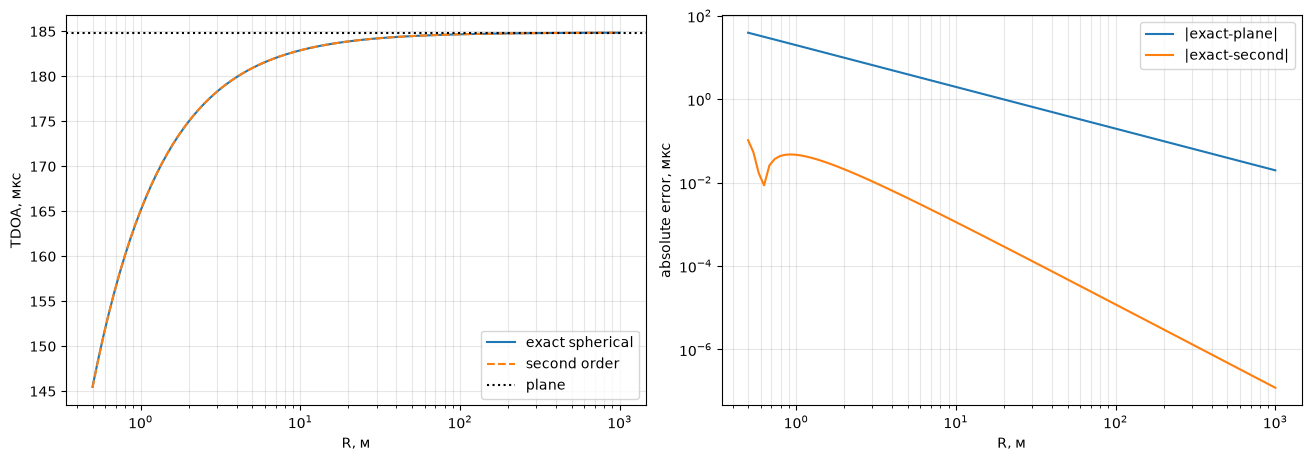

In [5]:
positions = arrays['L-shaped']
pairs = all_pairs(len(positions))
pair_index = pairs.index((0, 3))
phi, elevation = np.deg2rad([28.5, 20.0])
comparison_distances = np.logspace(np.log10(0.5), 3.0, 100)
plane_value = far_field_tdoa(phi, elevation, positions, pairs)[pair_index]
exact_values = np.asarray([directional_spherical_tdoa(phi, elevation, R, positions, pairs)[pair_index] for R in comparison_distances])
second_values = np.asarray([second_order_tdoa(phi, elevation, R, positions, pairs)[pair_index] for R in comparison_distances])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].semilogx(comparison_distances, exact_values * 1e6, label='exact spherical')
axes[0].semilogx(comparison_distances, second_values * 1e6, '--', label='second order')
axes[0].axhline(plane_value * 1e6, color='black', linestyle=':', label='plane')
axes[0].set_ylabel('TDOA, мкс')
axes[0].legend()
axes[1].loglog(comparison_distances, np.abs(exact_values-plane_value)*1e6, label='|exact-plane|')
axes[1].loglog(comparison_distances, np.abs(exact_values-second_values)*1e6, label='|exact-second|')
axes[1].set_ylabel('absolute error, мкс')
axes[1].legend()
for axis in axes:
    axis.set_xlabel('R, м')
    axis.grid(True, which='both', alpha=0.3)
plt.show()


## Точность двух дробных задержек

Положительная задержка означает $y[n]=x[n-d]$. Для тональных метрик исключено по 512 отсчётов с каждой границы. FIR: 129 taps, Kaiser beta=8.6, fixed latency 64 отсчёта компенсирована API.

fractional-delay records: 80 CSV: C:\Users\leo\Documents\Stu\APM\7sem\diploma\uav_acoustic_model\results\fractional_delay_accuracy.csv


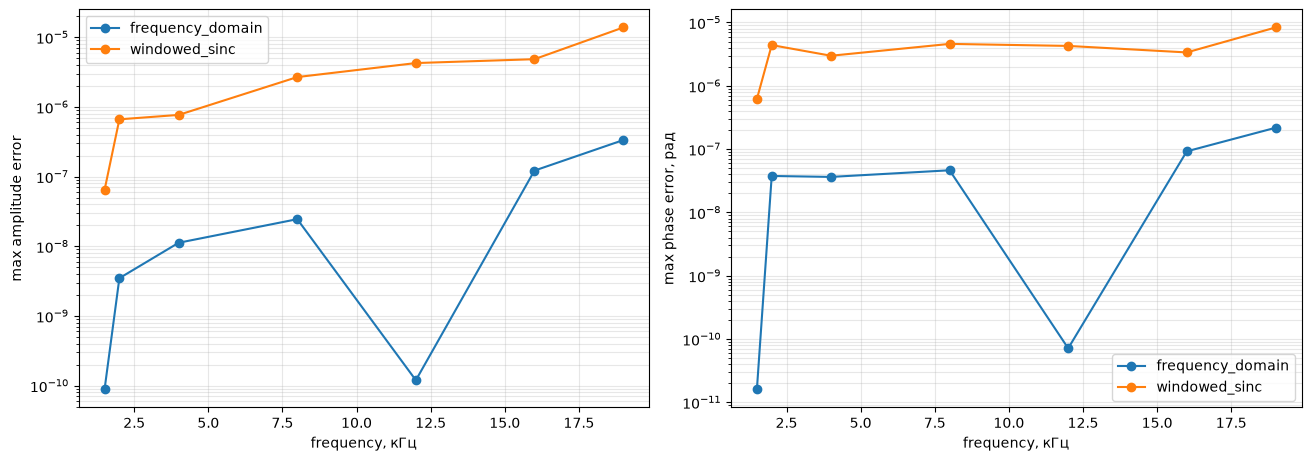

frequency_domain
  <=12 kHz max amplitude / phase: 2.445267510697846e-08 4.623404645160706e-08
  <=19 kHz max amplitude / phase: 3.343729690907793e-07 2.174526860493472e-07
  max waveform error (512 guard): 0.0009265991242497496
  max broadband group-delay error: 2.9558577807620168e-12
windowed_sinc
  <=12 kHz max amplitude / phase: 4.256536841662495e-06 4.58771428955905e-06
  <=19 kHz max amplitude / phase: 1.3820142275244862e-05 8.35057691771424e-06
  max waveform error (512 guard): 1.4578782694174564e-05
  max broadband group-delay error: 1.6592325664532837e-06
cross-method max broadband error: 2.022901879186745e-06


In [6]:
delay_records = run_fractional_delay_accuracy_study(output_csv=DELAY_CSV)
tone_rows = [row for row in delay_records if row['record_type'] == 'tone']
broadband_rows = [row for row in delay_records if row['record_type'] == 'broadband']
print('fractional-delay records:', len(delay_records), 'CSV:', DELAY_CSV)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for method in ('frequency_domain', 'windowed_sinc'):
    frequencies = np.asarray(FRACTIONAL_TEST_FREQUENCIES_HZ)
    amplitude = [max(row['amplitude_error'] for row in tone_rows if row['method']==method and row['frequency_hz']==frequency) for frequency in frequencies]
    phase = [max(row['phase_error_rad'] for row in tone_rows if row['method']==method and row['frequency_hz']==frequency) for frequency in frequencies]
    axes[0].semilogy(frequencies/1000, amplitude, 'o-', label=method)
    axes[1].semilogy(frequencies/1000, phase, 'o-', label=method)
axes[0].set_ylabel('max amplitude error')
axes[1].set_ylabel('max phase error, рад')
for axis in axes:
    axis.set_xlabel('frequency, кГц')
    axis.grid(True, which='both', alpha=0.3)
    axis.legend()
plt.show()

for method in ('frequency_domain', 'windowed_sinc'):
    application_rows = [row for row in tone_rows if row['method']==method and row['frequency_hz'] <= 12000]
    all_method_rows = [row for row in tone_rows if row['method']==method]
    group_rows = [row for row in broadband_rows if row['method']==method]
    print(method)
    print('  <=12 kHz max amplitude / phase:', max(row['amplitude_error'] for row in application_rows), max(row['phase_error_rad'] for row in application_rows))
    print('  <=19 kHz max amplitude / phase:', max(row['amplitude_error'] for row in all_method_rows), max(row['phase_error_rad'] for row in all_method_rows))
    print('  max waveform error (512 guard):', max(row['max_waveform_error_valid'] for row in all_method_rows))
    print('  max broadband group-delay error:', max(abs(row['group_delay_error_samples']) for row in group_rows))
print('cross-method max broadband error:', max(row['cross_method_max_error_valid'] for row in broadband_rows))


## Пример многоканального сигнала

Используется детерминированный tapered broadband multisine, а не модель БПЛА.

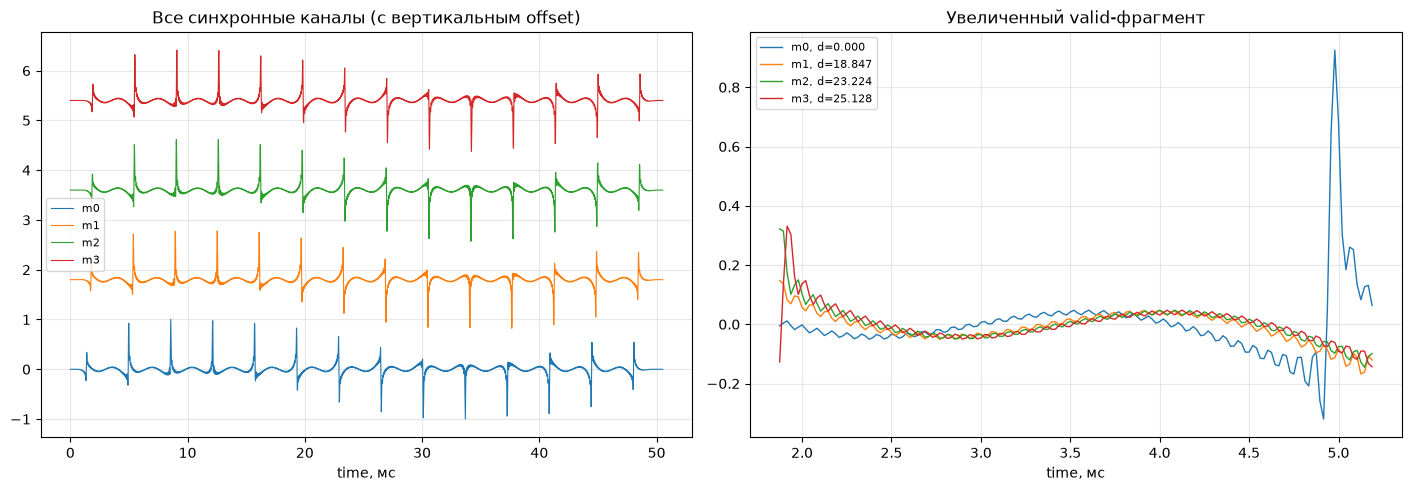

applied delay samples: [ 0.         18.84682587 23.22422528 25.12780672]
valid region: (90, 2336) output shape: (4, 2426)


In [7]:
fs = DIAGNOSTIC_SAMPLING_RATE_HZ
source_signal = deterministic_bandlimited_signal(fs, 0.05, minimum_frequency_hz=300, maximum_frequency_hz=12000, tone_count=41)
propagated = simulate_propagation(source_signal, fs, arrays['tetrahedral'], phi=np.deg2rad(35), elevation=np.deg2rad(25), distance_m=5.0, propagation_model='spherical')
time_ms = np.arange(propagated.channels.shape[1]) / fs * 1000
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for microphone, channel in enumerate(propagated.channels):
    axes[0].plot(time_ms, channel + 1.8*microphone, linewidth=0.8, label=f'm{microphone}')
zoom = slice(propagated.valid_region[0], propagated.valid_region[0] + 160)
for microphone, channel in enumerate(propagated.channels):
    axes[1].plot(time_ms[zoom], channel[zoom], linewidth=1.0, label=f'm{microphone}, d={propagated.applied_delay_samples[microphone]:.3f}')
axes[0].set_title('Все синхронные каналы (с вертикальным offset)')
axes[1].set_title('Увеличенный valid-фрагмент')
for axis in axes:
    axis.set_xlabel('time, мс')
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=8)
plt.show()
print('applied delay samples:', propagated.applied_delay_samples)
print('valid region:', propagated.valid_region, 'output shape:', propagated.channels.shape)


## Машинные критерии итогового исследования

In [8]:
assert len(sweep) == 5 * len(DISTANCES_M)
assert len(boundaries) == 5 * (1 + len(DIAGNOSTIC_MAXIMUM_FREQUENCIES_HZ))
assert all(row['achieved_error_s'] <= row['target_error_s'] for row in boundaries)
for name in arrays:
    rows = [row for row in sweep if row['geometry']==name][-5:]
    distance = np.asarray([row['distance_m'] for row in rows])
    plane_slope = np.polyfit(np.log(distance), np.log([row['max_plane_error_s'] for row in rows]), 1)[0]
    second_slope = np.polyfit(np.log(distance), np.log([row['max_second_order_error_s'] for row in rows]), 1)[0]
    assert -1.01 < plane_slope < -0.99
    assert -2.05 < second_slope < -1.95
application_tones = [row for row in tone_rows if row['frequency_hz'] <= 12000]
extended_fir_tones = [row for row in tone_rows if row['method']=='windowed_sinc' and row['frequency_hz'] <= 19000]
assert max(row['amplitude_error'] for row in application_tones) < 1e-5
assert max(row['phase_error_rad'] for row in application_tones) < 1e-5
assert max(row['amplitude_error'] for row in extended_fir_tones) < 2e-5
assert all(row['relative_grid_difference'] <= 1e-4 for row in boundaries)
assert max(abs(row['group_delay_error_samples']) for row in broadband_rows) < 2e-6
assert max(row['cross_method_max_error_valid'] for row in broadband_rows) < 3e-6
assert FAR_FIELD_CSV.exists() and DELAY_CSV.exists()
print('PASS: asymptotic slopes, numerical boundaries, grid convergence, fractional-delay accuracy and CSV outputs')


PASS: asymptotic slopes, numerical boundaries, grid convergence, fractional-delay accuracy and CSV outputs
